# Aktivitelere Göre Verimlilik Analizi (v1.0)

Bu analiz, günlük bireysel çalışmamın verimini etkileyen ana olayların, kendi tasarladığım kişisel disiplin takibi tablosundaki çeşitli formüllerden geçerek o günün ne kadar verimli geçtiğini gösteren sayısal değeri nasıl etkilediğini göstermektedir.

Bu sayede bireysel çalışma verimini etkilediğini düşündüğüm dört ana olaydan *(spora gitmek, dinç uyanmak, kahve içmek, okula gitmek)* hangilerinin nasıl bir etkisi *(pozitif/negatif)* olduğunu göreceğiz.

In [1]:
import pandas as pd
import numpy as np

Gerekli kütüphanelerimizi dahil ediyoruz.

In [2]:
dataset = pd.read_excel("/content/drive/MyDrive/Discipline/04-2026.xlsx")

In [3]:
dataset.head()

,Günler,Bireysel Çalışma (Dakika),Kitap (Sayfa),Bulmaca (Dakika),Belgesel (Adet),Film (Adet),Sayısal Verim Değeri,Verimli Mi?,Spora gittin mi?,Dinç kalktın mı?,Kahve içtin mi?,Okula gittin mi?
0,2025-05-01 00:00:00,165,0,0,0,0,1.65,Ortalama,Evet,Evet,Hayır,Hayır
1,2025-05-02 00:00:00,15,0,0,0,0,0.15,Verimsiz,Hayır,Hayır,Hayır,Evet
2,2025-05-03 00:00:00,240,0,0,0,0,2.4,Ortalama,Hayır,Evet,Evet,Hayır
3,2025-05-04 00:00:00,180,20,0,0,0,2,Ortalama,Hayır,Evet,Hayır,Hayır
4,2025-05-05 00:00:00,270,10,10,0,0,2.9,Verimli,Evet,Evet,Evet,Hayır


Verisetimizdeki sütun ve satırlar hakkında kabaca bilgi sahibi oluyoruz.

In [4]:
df = dataset[['Sayısal Verim Değeri', "Spora gittin mi?", "Dinç kalktın mı?", "Kahve içtin mi?", "Okula gittin mi?"]]

In [5]:
df.head()

,Sayısal Verim Değeri,Spora gittin mi?,Dinç kalktın mı?,Kahve içtin mi?,Okula gittin mi?
0,1.65,Evet,Evet,Hayır,Hayır
1,0.15,Hayır,Hayır,Hayır,Evet
2,2.4,Hayır,Evet,Evet,Hayır
3,2,Hayır,Evet,Hayır,Hayır
4,2.9,Evet,Evet,Evet,Hayır


İhtiyacımız olan sütunları **df** adlı değişkene atıyoruz.

In [6]:
df = df.replace({'Evet': 1, 'Hayır': 0})

/tmp/ipykernel_19835/677802536.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Evet': 1, 'Hayır': 0})


In [7]:
df.head()

,Sayısal Verim Değeri,Spora gittin mi?,Dinç kalktın mı?,Kahve içtin mi?,Okula gittin mi?
0,1.65,1.0,1.0,0.0,0.0
1,0.15,0.0,0.0,0.0,1.0
2,2.4,0.0,1.0,1.0,0.0
3,2,0.0,1.0,0.0,0.0
4,2.9,1.0,1.0,1.0,0.0


Gerekli nümerik dönüşümleri yapıyoruz.

In [8]:
cols = ['Spora gittin mi?', 'Dinç kalktın mı?', 'Kahve içtin mi?', 'Okula gittin mi?']

In [9]:
for col in ['Spora gittin mi?', 'Dinç kalktın mı?', 'Kahve içtin mi?', 'Okula gittin mi?']:
    print(f"{col}: {df[col].sum()}")

Spora gittin mi?: 11.0
Dinç kalktın mı?: 20.0
Kahve içtin mi?: 7.0
Okula gittin mi?: 8.0


Bu ay kaç defa spora gittiğimizi, kaç gün dinç uyandığımızı, kaç defa kahve içtiğimizi ve kaç defa okula gittiğimizi görüyoruz.

In [19]:
df['Sayısal Verim Değeri'] = pd.to_numeric(df['Sayısal Verim Değeri'], errors='coerce')

In [20]:
df['Sayısal Verim Değeri'].describe()

,Sayısal Verim Değeri
count,31.000000
mean,1.040000
std,0.773994
min,0.000000
25%,0.475000
50%,1.150000
75%,1.300000
max,2.900000


Günlük verim skorumuzun 0.77 sapmayla **ortalama 1.04** olduğunu görüyoruz.

In [21]:
for col in cols:
    print(df.groupby(col)['Sayısal Verim Değeri'].mean())
    print("------")

Spora gittin mi?
0.0    0.934211
1.0    1.222727
Name: Sayısal Verim Değeri, dtype: float64
------
Dinç kalktın mı?
0.0    0.870
1.0    1.125
Name: Sayısal Verim Değeri, dtype: float64
------
Kahve içtin mi?
0.0    0.904348
1.0    1.485714
Name: Sayısal Verim Değeri, dtype: float64
------
Okula gittin mi?
0.0    1.393182
1.0    0.068750
Name: Sayısal Verim Değeri, dtype: float64
------


*(Aslında bu kısımda amacımıza ulaşıyoruz.)* Bir olayın olduğu veya olmadığı günlerdeki verim skorunun ortalamasını görüyoruz.

In [22]:
import seaborn as sns

<Axes: >

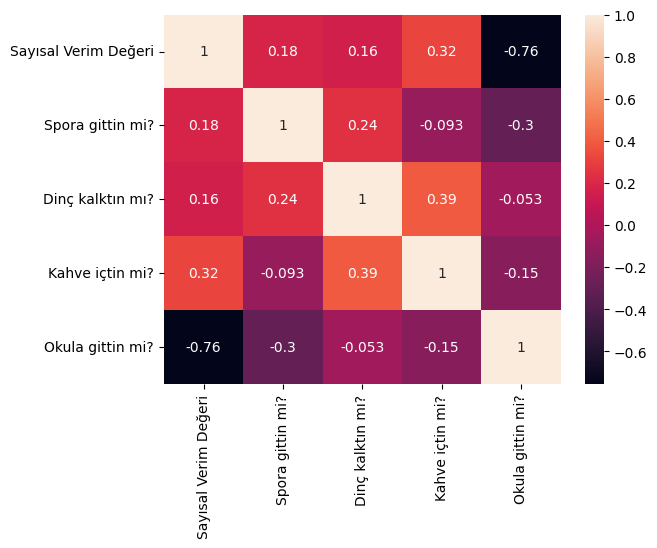

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Daha görsel bir şekilde, korelasyon haritasında da hangi değişkenin bir diğerini nasıl *(pozitif/negatif)* etkilediğini görüyoruz.

In [14]:
import matplotlib.pyplot as plt

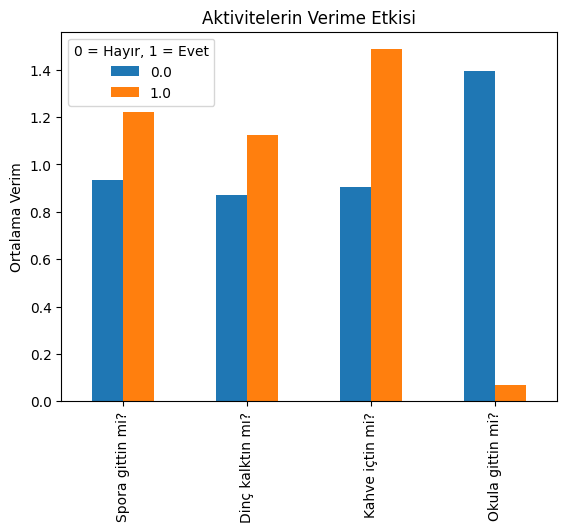

In [17]:
result = pd.DataFrame()

for col in cols:
    result[col] = df.groupby(col)['Sayısal Verim Değeri'].mean()

result.T.plot(kind='bar')

plt.title("Aktivitelerin Verime Etkisi")
plt.ylabel("Ortalama Verim")
plt.legend(title="0 = Hayır, 1 = Evet")
plt.show()

Sonuç olarak:
*   Spora gittiğim
*   Dinç kalktığım
*   Kahve içtiğim

günler verim skorunu **pozitif** etkilerken, okula gitmek oldukça **negatif** etkiliyor.

Ancak bu verim skorunun gösterdiği verim, **bireysel çalışma** için geçerlidir. Bu yüzden okula gitmemek daha verimlidir gibi bir çıkarım, **asla** söz konusu değildir.

Okula gitmediğim günlerde dinç uyanır, kahve içer ve spora gidersem o günün veriminin artacağı **bariz** bir şekilde gözükmektedir.

Bir sonraki Aktivitelere Göre Verimlilik Analizi (v2.0)'nde sütunlara ek olarak *'Akşam dışarı çıktın mı?'* ile *'Erken uyandın mı? (<10)'* eklenecektir.

